## 1. Introduction: Grassland Segmentation

In this notebook, we adapt our high-speed global rasterization pipeline to generate masks for **Grassland** (and similar green groundcover). 

**Key Changes from the Built-up Pipeline:**
1. We target a new output directory (`masks_grassland`).
2. We shift our focus to a deeper level of the biotope hierarchy: `lrtyp2code`.
3. Because "Grassland" might encompass several sub-classes (e.g., meadows, lawns, pastures), we use a **list of target codes** to map multiple specific biotope types to our positive class (`1`). All other classes default to `0`.

In [9]:
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.windows import from_bounds
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# --- Directory Configuration ---
BASE_OUT = "../data/processed_modular"
META_DIR = f"{BASE_OUT}/metadata"
MASK_TASK_NAME = "masks_grassland" # Changed for this specific task
GLOBAL_MASK_PATH = f"{META_DIR}/global_grassland_mask_2056.tif"
BIOTOPE_PATH = "/Users/fadricampell/Documents/HSLU/Modules/rBootcamp/r-bootcamp/data/biotoptypen2020/data/gsz.btk_2020.shp"
ANCHOR_PATH = f"{META_DIR}/building_anchors_2000.gpkg"

# --- Hyperparameters ---
# These MUST match Notebook 1 exactly to ensure spatial alignment
CROP_RADIUS_M = 50 
IMG_SIZE = 512
TARGET_RES = 100.0 / 512.0  # Approx 0.195m per pixel

## 2. Preparing the Biotope Data & Exploring Level 2 Classes

We load the Biotope mapping data and look at the `lrtyp2` (Level 2) classes. First, we print the statistics to help us identify exactly which codes represent the grass-like covers we want. 

Then, we define a list of target codes. Any polygon matching a code in this list becomes a `1` (Grassland), and everything else becomes `0`.

In [7]:
print("Loading biotope vectors...")
gdf = gpd.read_file(BIOTOPE_PATH)

if gdf.crs.to_string() != 'EPSG:2056':
    gdf = gdf.to_crs(epsg=2056)

# --- Explore the Level 2 Classes ---
class_id   = 'lrtyp2code'
class_name = 'lrtyp2text'

gdf['area_sqm'] = gdf.geometry.area
class_stats = gdf.groupby([class_id, class_name]).agg(
    total_area_sqm=('area_sqm', 'sum')
).reset_index().sort_values(by='lrtyp2code', ascending=True)

print("\n--- Level 2 Biotope Class Statistics ---")
print(class_stats.to_string(index=False)) # Print top 15 to keep output clean

# ==========================================
# TODO: Update this list with the exact string codes for Grassland from the printed stats above!
TARGET_CODES = [
    "08.04",  # Kalk-Magerrasen
    "08.07",  # Sonstiger Magerrasen
    "08.08", # Artenarmes Magerwiesenstadium
    "09.01", # Mesophiles Grünland
    "09.03", # Nasswiese
    "09.05", # Artenarmes Grünland
    "10.02", # Gartenbaufläche
    "11.01", # Ruderalflur
    "11.02", # Halbruderale Gras- und Staudenflur
    "11.03", # Artenarme Neophytenflur
    "12.01", # Scher- und Trittrasen
    "12.02", # Ziergebüsch/-hecke
    #"12.03",# Gehölz des Siedlungsbereichs
    "12.04", # Einzelbaum/ Baumraster des  Siedlungsbereichs
    "12.05", # Beet/ Rabatte
    "12.06", # Hausgarten
    "12.07", # Familiengartenanlage
    "12.08", # Parkanlage
    "12.09", # Friedhof
    "12.10", # Tiergehege
    "12.11", # Sport-/Spiel-/Erholungsanlage
    "12.12"  # Grünanlage von Mehrfamilienhäusern 
] 

# Binary Labeling: 1 if the code is in our target list, 0 otherwise
gdf['grassland_mask_val'] = gdf[class_id].astype(str).isin(TARGET_CODES).astype(int)

print(f"\nMask Distribution:")
print(gdf['grassland_mask_val'].value_counts())

Loading biotope vectors...

--- Level 2 Biotope Class Statistics ---
lrtyp2code                                                                lrtyp2text  total_area_sqm
     01.00                                                            Wald allgemein    2.138555e+07
     01.11                                                       Aronstab-Buchenwald    2.208855e+02
     01.30                                                Traubenkirschen-Eschenwald    1.128922e+02
     01.44                                              Seggen-Schwarzerlenbruchwald    3.403347e+03
     01.94                                                                  Waldrand    1.305022e+04
     01.96                                                           Holzlagerfläche    2.740147e+03
     02.02                                                        mesophiles Gebüsch    1.918275e+03
     02.05                                           Weidengebüsch der Auen und Ufer    1.368708e+04
     02.06            

## 3. Creating the Global Grassland Mask

We burn the targeted polygons into our high-resolution global raster. If this file already exists from a previous run, we skip the heavy geometry calculations and reuse it.

In [8]:
if not os.path.exists(GLOBAL_MASK_PATH):
    print("Generating Global Grassland Raster (this may take a minute)...")
    
    minx, miny, maxx, maxy = gdf.total_bounds
    width = math.ceil((maxx - minx) / TARGET_RES)
    height = math.ceil((maxy - miny) / TARGET_RES)
    
    global_transform = rasterio.transform.from_origin(minx, maxy, TARGET_RES, TARGET_RES)
    
    global_mask_array = features.rasterize(
        shapes=((geom, val) for geom, val in zip(gdf.geometry, gdf['grassland_mask_val'])),
        out_shape=(height, width),
        transform=global_transform,
        fill=0,
        dtype=rasterio.uint8
    )
    
    with rasterio.open(
        GLOBAL_MASK_PATH, 'w',
        driver='GTiff', height=height, width=width, count=1, 
        dtype=rasterio.uint8, crs='EPSG:2056', transform=global_transform, compress='lzw'
    ) as ds:
        ds.write(global_mask_array, 1)
    print(f"✅ Global mask created: {width}x{height} pixels.")
else:
    print(f"✅ Reusing existing global mask: {GLOBAL_MASK_PATH}")

Generating Global Grassland Raster (this may take a minute)...
✅ Global mask created: 68819x65138 pixels.


## 3.1. Visual Validation of the Global Raster
Before extracting individual patches, we visualize the entire global raster. This allows us to ensure that the coordinate transform is correct and that the "Grassland" polygons have been "burned" into the image in the correct locations across the City of Zürich.

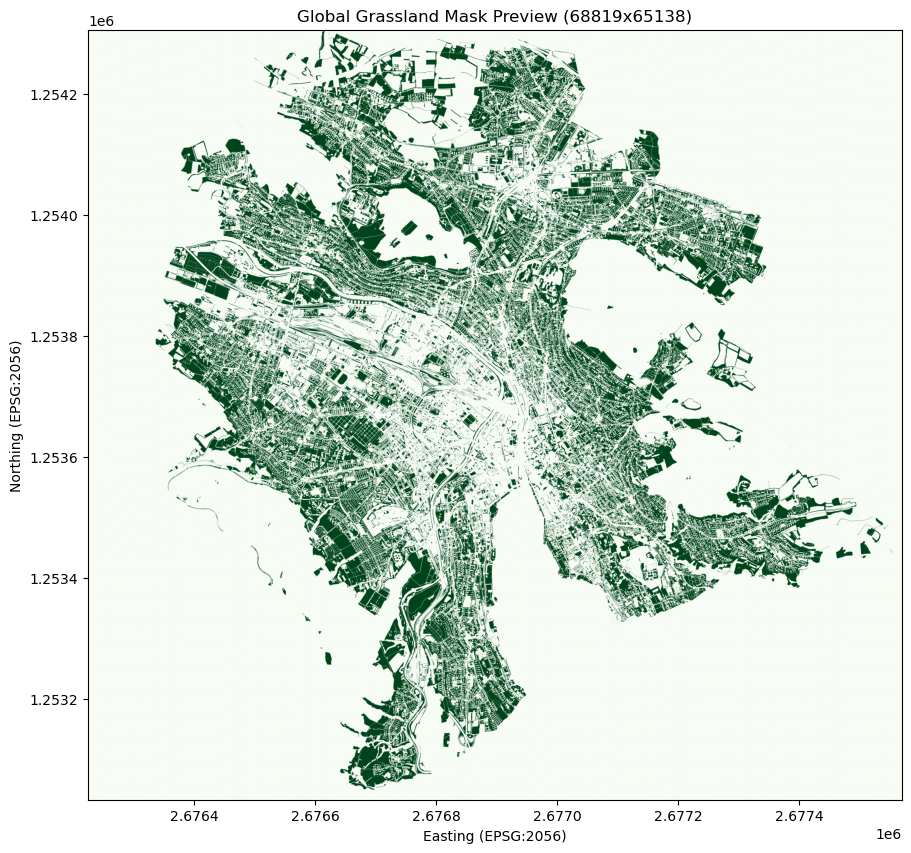

Global Raster Stats:
 - Min Value: 0
 - Max Value: 1 (Should be 1)
 - Shape: (65138, 68819)


In [11]:
import rasterio.plot

with rasterio.open(GLOBAL_MASK_PATH) as src:
    # We read at a lower resolution (out_shape) just for the preview 
    # to save memory and speed up plotting
    preview_factor = 10 # Adjust this if you want more/less detail
    preview_data = src.read(
        1, 
        out_shape=(1, int(src.height // preview_factor), int(src.width // preview_factor)),
        resampling=rasterio.enums.Resampling.nearest
    )
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use 'show' from rasterio.plot to keep the coordinates on the axes
    rasterio.plot.show(preview_data, transform=src.transform, ax=ax, cmap='Greens')
    
    ax.set_title(f"Global Grassland Mask Preview ({src.width}x{src.height})")
    ax.set_xlabel("Easting (EPSG:2056)")
    ax.set_ylabel("Northing (EPSG:2056)")
    
    plt.show()

print(f"Global Raster Stats:")
print(f" - Min Value: {preview_data.min()}")
print(f" - Max Value: {preview_data.max()} (Should be 1)")
print(f" - Shape: {src.shape}")

## 4. Extracting Localized Patches

We load our exact same spatial anchors from Notebook 1. Using the bounding boxes defined by those anchors, we slice out the corresponding 512x512 pixel patches from our global Grassland raster.

In [12]:
gdf_anchors = gpd.read_file(ANCHOR_PATH)

with rasterio.open(GLOBAL_MASK_PATH) as src_global:
    for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
        uid = row['unique_id']
        split = row['split']
        out_folder = f"{BASE_OUT}/{split}/{MASK_TASK_NAME}"
        os.makedirs(out_folder, exist_ok=True)
        
        out_path = f"{out_folder}/{uid}_mask.tif"
        if os.path.exists(out_path): continue
        
        win_minx, win_maxx = row['x_2056'] - CROP_RADIUS_M, row['x_2056'] + CROP_RADIUS_M
        win_miny, win_maxy = row['y_2056'] - CROP_RADIUS_M, row['y_2056'] + CROP_RADIUS_M
        
        window = from_bounds(win_minx, win_miny, win_maxx, win_maxy, src_global.transform)
        
        mask_patch = src_global.read(1, window=window, boundless=True, fill_value=0, out_shape=(IMG_SIZE, IMG_SIZE))
        
        patch_meta = src_global.meta.copy()
        patch_meta.update({
            "height": IMG_SIZE, "width": IMG_SIZE,
            "transform": rasterio.windows.transform(window, src_global.transform)
        })
        
        with rasterio.open(out_path, 'w', **patch_meta) as dest:
            dest.write(mask_patch, 1)

print("✅ Mask extraction complete.")

  0%|          | 0/2000 [00:00<?, ?it/s]

✅ Mask extraction complete.


## 5. Sanity Check: Mask Alignment

We overlay a random aerial image with its corresponding Grassland mask to visually verify the alignment and ensure we captured the correct groundcover types.

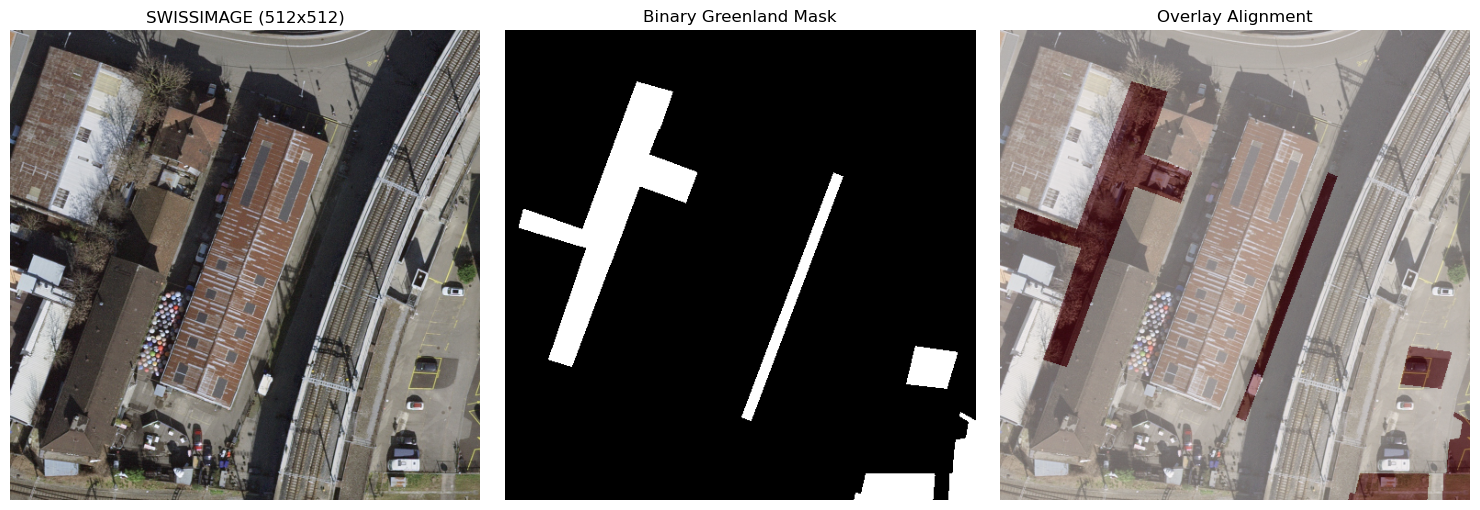

In [15]:
# Grab a random anchor from the training set
sample_row = gdf_anchors[gdf_anchors['split'] == 'train'].sample().iloc[0]
uid = sample_row['unique_id']

img_path = f"{BASE_OUT}/train/images/{uid}_swissimage.tif"
mask_path = f"{BASE_OUT}/train/{MASK_TASK_NAME}/{uid}_mask.tif"

if os.path.exists(img_path) and os.path.exists(mask_path):
    with rasterio.open(img_path) as src_img:
        # Swisstopo might return 3 (RGB) or 4 (RGBA) channels
        img = src_img.read()[:3] 
        # Convert from (C, H, W) to (H, W, C) for matplotlib
        img = np.moveaxis(img, 0, -1) 
        
    with rasterio.open(mask_path) as src_mask:
        mask = src_mask.read(1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(img)
    axs[0].set_title("SWISSIMAGE (512x512)")
    axs[0].axis("off")
    
    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Binary Greenland Mask")
    axs[1].axis("off")
    
    # Overlay
    axs[2].imshow(img)
    axs[2].imshow(mask, cmap="Reds", alpha=0.4) # Overlay mask in semi-transparent red
    axs[2].set_title("Overlay Alignment")
    axs[2].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find both files for UID: {uid}. Ensure Notebook 1 ran successfully.")